In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [3]:
from src.imports import *

df = pd.read_pickle('../output/ch1/dataset_lcforest_noLOF_bin15_th3_80m_1kmsmallbox_noprior_ta_dw1_v7.pkl')
df['Eg_strong'] = np.where((df['beam_str'] == 'strong')&(df['outlier'] == 1), df['Eg'], np.nan)
df['Ev_strong'] = np.where((df['beam_str'] == 'strong')&(df['outlier'] == 1), df['Ev'], np.nan)
df['Eg_weak'] = np.where((df['beam_str'] == 'weak')&(df['outlier'] == 1), df['Eg'], np.nan)
df['Ev_weak'] = np.where((df['beam_str'] == 'weak')&(df['outlier'] == 1), df['Ev'], np.nan)
df['forest_type'] = np.where(df['segment_landcover']<119, 'closed', 'open')

df_grouped = df.groupby(['camera','date','lat','lon']).agg({
    'pvpg': 'mean',
    'pv': 'max',
    'pg': 'max',
    'Eg_strong': 'median',
    'Ev_strong': 'median',
    'Eg_weak': 'median',
    'Ev_weak': 'median',
    'data_quantity': 'max',
    'snr': 'mean',
    'FSC': 'mean',
    'TreeSnow': 'mean',
    'layer_flag': 'mean',
    'file_index': 'mean',
    'msw_flag': 'mean',
    'pv_ratio_mean': 'mean',
    'pv_ratio_max': 'mean',
    'forest_type': lambda x: pd.Series.mode(x).iloc[0],
}).reset_index()
df_grouped['JointSnow'] = df_grouped['FSC'] + df_grouped['TreeSnow']

data = df_grouped[((df_grouped['FSC'] <= 0.005)|(df_grouped['FSC'] >= 0.995))
    &((df_grouped['TreeSnow'] == 0)|(df_grouped['TreeSnow'] == 1))
    &(df_grouped['Eg_strong']/df_grouped['Eg_weak'] >= 1.15)
    &(df_grouped['data_quantity'] >= 26)]
data.loc[:, 'JointSnow'] = data['JointSnow'].apply(lambda x: np.round(x))
data["Conditions"] = data["JointSnow"].map({0: "No Snow", 1: "Ground Snow", 2: "Ground and Canopy Snow"})

/tmp/ipykernel_3141408/2875583580.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Conditions"] = data["JointSnow"].map({0: "No Snow", 1: "Ground Snow", 2: "Ground and Canopy Snow"})


0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100
5200
5300
5400
5500
5600
5700
5800
5900
6000
6100
6200
6300
6400
6500
6600
6700
6800
6900
7000
7100
7200
7300
7400
7500
7600
7700
7800
7900
8000
8100
8200
8300
8400
8500
8600
8700
8800
8900
9000
9100
9200
9300
9400
9500
9600
9700
9800
9900


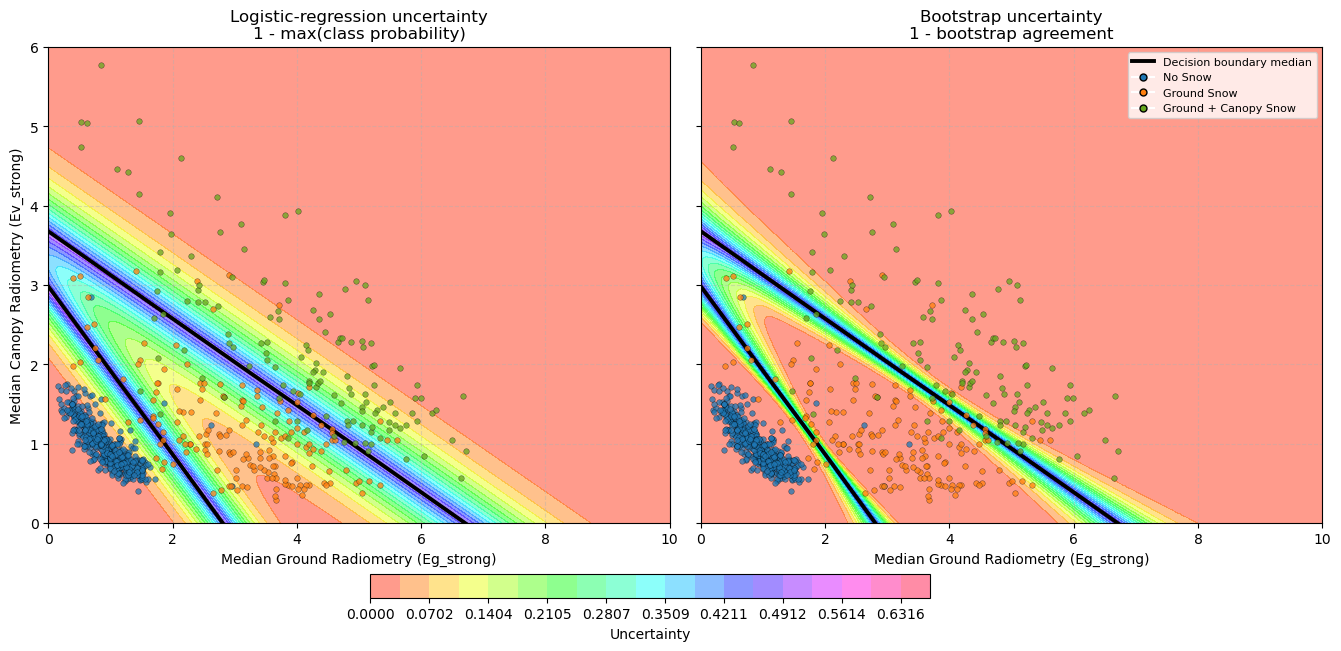

Valid bootstrap models: 10000

No Snow vs Ground Snow
----------------------
n = 10000
slope median     = -1.0665356431227757
slope std        = 0.2763414301297723
intercept median = 2.9820511055577317
intercept std    = 0.4961441515028746

Ground Snow vs Ground + Canopy Snow
-----------------------------------
n = 10000
slope median     = -0.5493483525086611
slope std        = 0.1063551409366942
intercept median = 3.6763558570111456
intercept std    = 0.41237318920565763


In [4]:
from sklearn.linear_model import LogisticRegression

# -----------------------------
# Settings
# -----------------------------
N_BOOT = 10000

EG_COL = "Eg_strong"
EV_COL = "Ev_strong"
CLASS_COL = "JointSnow"

PLOT_XLIM = (0, 10)
PLOT_YLIM = (0, 6)

GRID_N = 250

pairs = {
    "01": (0, 1, "No Snow vs Ground Snow"),
    "12": (1, 2, "Ground Snow vs Ground + Canopy Snow"),
}

colors = {
    "01": "#d62728",
    "12": "#2ca02c",
}

class_labels = {
    0: "No Snow",
    1: "Ground Snow",
    2: "Ground + Canopy Snow",
}

# -----------------------------
# Data and grid
# -----------------------------
plot_df = data.dropna(subset=[EG_COL, EV_COL, CLASS_COL]).copy()
plot_df[CLASS_COL] = plot_df[CLASS_COL].astype(int)

x_grid = np.linspace(PLOT_XLIM[0], PLOT_XLIM[1], GRID_N)
y_grid = np.linspace(PLOT_YLIM[0], PLOT_YLIM[1], GRID_N)

xx, yy = np.meshgrid(x_grid, y_grid)
grid_X = np.column_stack([xx.ravel(), yy.ravel()])

all_cameras = sorted(plot_df["camera"].unique())
rng = np.random.RandomState(42)

boot_lines = {
    "01": [],
    "12": [],
}

vote_counts = np.zeros((3, len(grid_X)), dtype=int)

# -----------------------------
# Full model: logistic-regression uncertainty
# -----------------------------
full_model = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    random_state=0,
)

full_model.fit(
    plot_df[[EG_COL, EV_COL]].values,
    plot_df[CLASS_COL].values,
)

# -----------------------------
# Export logistic uncertainty surface
# -----------------------------
EXPORT_XLIM = (0, 16)
EXPORT_YLIM = (0, 16)
EXPORT_GRID_N = 801   # 0.02 spacing across 0–16

export_x_grid = np.linspace(EXPORT_XLIM[0], EXPORT_XLIM[1], EXPORT_GRID_N)
export_y_grid = np.linspace(EXPORT_YLIM[0], EXPORT_YLIM[1], EXPORT_GRID_N)

export_xx, export_yy = np.meshgrid(export_x_grid, export_y_grid)

export_grid_X = np.column_stack([
    export_xx.ravel(),
    export_yy.ravel(),
])

export_probs = full_model.predict_proba(export_grid_X)

# Align probabilities into columns [class 0, class 1, class 2]
export_probs_aligned = np.zeros((len(export_grid_X), 3))

for n, cls in enumerate(full_model.classes_):
    export_probs_aligned[:, int(cls)] = export_probs[:, n]

export_logistic_uncertainty = 1 - export_probs_aligned.max(axis=1)
export_logistic_uncertainty = export_logistic_uncertainty.reshape(export_xx.shape)

export_pred_class = export_probs_aligned.argmax(axis=1)
export_pred_class = export_pred_class.reshape(export_xx.shape)

# Save as xarray Dataset
ds_uncertainty = xr.Dataset(
    data_vars={
        "logistic_uncertainty": (
            [EV_COL, EG_COL],
            export_logistic_uncertainty.astype("float32"),
        ),
        "predicted_class": (
            [EV_COL, EG_COL],
            export_pred_class.astype("int8"),
        ),
        "prob_no_snow": (
            [EV_COL, EG_COL],
            export_probs_aligned[:, 0].reshape(export_xx.shape).astype("float32"),
        ),
        "prob_ground_snow": (
            [EV_COL, EG_COL],
            export_probs_aligned[:, 1].reshape(export_xx.shape).astype("float32"),
        ),
        "prob_ground_canopy_snow": (
            [EV_COL, EG_COL],
            export_probs_aligned[:, 2].reshape(export_xx.shape).astype("float32"),
        ),
    },
    coords={
        EG_COL: export_x_grid.astype("float32"),
        EV_COL: export_y_grid.astype("float32"),
    },
    attrs={
        "description": "Logistic-regression classification uncertainty surface",
        "uncertainty_definition": "1 - max(class probability)",
        "model": "sklearn LogisticRegression",
        "Eg_column": EG_COL,
        "Ev_column": EV_COL,
        "class_column": CLASS_COL,
        "x_range": str(EXPORT_XLIM),
        "y_range": str(EXPORT_YLIM),
        "grid_n": EXPORT_GRID_N,
    },
)

ds_uncertainty.to_netcdf("../output/logistic_uncertainty_EgEv.nc")

#########

full_probs = full_model.predict_proba(grid_X)

# Align probabilities into columns [class 0, class 1, class 2]
full_probs_aligned = np.zeros((len(grid_X), 3))

for n, cls in enumerate(full_model.classes_):
    full_probs_aligned[:, int(cls)] = full_probs[:, n]

logistic_uncertainty = 1 - full_probs_aligned.max(axis=1)
logistic_uncertainty = logistic_uncertainty.reshape(xx.shape)

# -----------------------------
# Bootstrap models
# -----------------------------
n_valid_boot = 0

for i in range(N_BOOT):
    if i % 100 == 0:
        print(i)

    sampled_cameras = rng.choice(
        all_cameras,
        size=len(all_cameras),
        replace=True,
    )

    boot_df = pd.concat(
        [plot_df[plot_df["camera"] == cam] for cam in sampled_cameras],
        ignore_index=True,
    )

    # Need all three classes to estimate both boundaries
    if set(boot_df[CLASS_COL].unique()) != {0, 1, 2}:
        continue

    X = boot_df[[EG_COL, EV_COL]].values
    y = boot_df[CLASS_COL].values

    model = LogisticRegression(
        solver="lbfgs",
        max_iter=1000,
        random_state=0,
    )

    model.fit(X, y)

    classes = list(model.classes_)

    # Save boundary lines
    for key, (class_a, class_b, label) in pairs.items():
        ia = classes.index(class_a)
        ib = classes.index(class_b)

        w = model.coef_[ia] - model.coef_[ib]
        b = model.intercept_[ia] - model.intercept_[ib]

        slope = -w[0] / w[1]
        intercept = -b / w[1]

        boot_lines[key].append((slope, intercept))

    # Save bootstrap class vote across the grid
    probs = model.predict_proba(grid_X)

    probs_aligned = np.zeros((len(grid_X), 3))

    for n, cls in enumerate(model.classes_):
        probs_aligned[:, int(cls)] = probs[:, n]

    pred_class = probs_aligned.argmax(axis=1)

    for cls in [0, 1, 2]:
        vote_counts[cls] += pred_class == cls

    n_valid_boot += 1

# -----------------------------
# Bootstrap uncertainty
# -----------------------------
bootstrap_agreement = vote_counts.max(axis=0) / n_valid_boot
bootstrap_uncertainty = 1 - bootstrap_agreement
bootstrap_uncertainty = bootstrap_uncertainty.reshape(xx.shape)

# -----------------------------
# Boundary summaries
# -----------------------------
boundary_summary = {}

for key, (class_a, class_b, label) in pairs.items():
    lines = np.array(boot_lines[key])

    slopes = lines[:, 0]
    intercepts = lines[:, 1]

    y_boot = slopes[:, None] * x_grid[None, :] + intercepts[:, None]

    y16, y50, y84 = np.percentile(y_boot, [16, 50, 84], axis=0)

    boundary_summary[key] = {
        "label": label,
        "slopes": slopes,
        "intercepts": intercepts,
        "y16": y16,
        "y50": y50,
        "y84": y84,
        "n": len(lines),
    }

# -----------------------------
# Plot uncertainty surfaces
# -----------------------------
fig = plt.figure(figsize=(14, 6.8))

ax0 = fig.add_subplot(1, 2, 1)
ax1 = fig.add_subplot(1, 2, 2, sharex=ax0, sharey=ax0)
axes = [ax0, ax1]

# Leave real space at bottom for colorbar
fig.subplots_adjust(
    left=0.07,
    right=0.98,
    top=0.88,
    bottom=0.18,
    wspace=0.05,
)

plot_specs = [
    (axes[0], logistic_uncertainty, "Logistic-regression uncertainty\n1 - max(class probability)"),
    (axes[1], bootstrap_uncertainty, "Bootstrap uncertainty\n1 - bootstrap agreement"),
]

point_colors = {
    0: "#1f77b4",
    1: "#ff7f0e",
    2: "#66a61e",
}

for ax, uncertainty, title in plot_specs:
    im = ax.contourf(
        xx,
        yy,
        uncertainty,
        levels=np.linspace(0, 2/3, 20),
        cmap="hsv",
        alpha=0.45,
    )

    for key, s in boundary_summary.items():
        ax.plot(
            x_grid,
            s["y50"],
            color="black",
            lw=2.8,
            zorder=3,
            label=f"{s['label']} median",
        )

    for cls in sorted(plot_df[CLASS_COL].unique()):
        mask = plot_df[CLASS_COL] == cls

        ax.scatter(
            plot_df.loc[mask, EG_COL],
            plot_df.loc[mask, EV_COL],
            s=16,
            alpha=0.75,
            color=point_colors[cls],
            edgecolors="black",
            linewidths=0.25,
            zorder=4,
            label=class_labels[cls],
        )

    ax.set_title(title)
    ax.set_xlabel(f"Median Ground Radiometry ({EG_COL})")
    ax.set_xlim(*PLOT_XLIM)
    ax.set_ylim(*PLOT_YLIM)
    ax.grid(True, linestyle="--", alpha=0.4)

axes[0].set_ylabel(f"Median Canopy Radiometry ({EV_COL})")

# Hide repeated y tick labels on right plot
plt.setp(axes[1].get_yticklabels(), visible=False)

# Dedicated colorbar axis: [left, bottom, width, height]
cbar_ax = fig.add_axes([0.30, 0.07, 0.40, 0.035])

cbar = fig.colorbar(
    im,
    cax=cbar_ax,
    orientation="horizontal",
)

cbar.set_label("Uncertainty")

handles = [
    plt.Line2D([0], [0], color="black", lw=2.8, label="Decision boundary median"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=point_colors[0], markeredgecolor="black", markersize=5, label="No Snow"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=point_colors[1], markeredgecolor="black", markersize=5, label="Ground Snow"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=point_colors[2], markeredgecolor="black", markersize=5, label="Ground + Canopy Snow"),
]

axes[1].legend(
    handles=handles,
    loc="upper right",
    fontsize=8,
    frameon=True,
)

plt.show()

# -----------------------------
# Summary
# -----------------------------
print(f"Valid bootstrap models: {n_valid_boot}")

for key, s in boundary_summary.items():
    print(f"\n{s['label']}")
    print("-" * len(s["label"]))
    print(f"n = {s['n']}")
    print(f"slope median     = {np.median(s['slopes'])}")
    print(f"slope std        = {np.std(s['slopes'])}")
    print(f"intercept median = {np.median(s['intercepts'])}")
    print(f"intercept std    = {np.std(s['intercepts'])}")

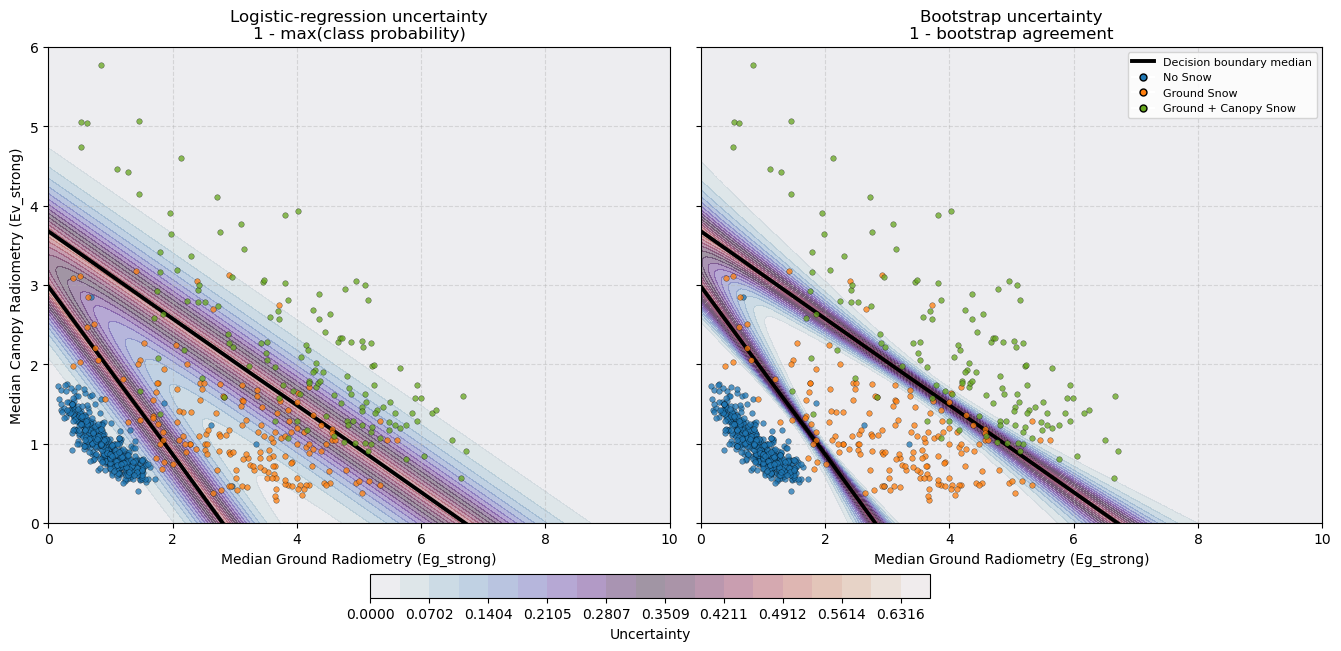

In [5]:
# -----------------------------
# Plot uncertainty surfaces
# -----------------------------
fig = plt.figure(figsize=(14, 6.8))

ax0 = fig.add_subplot(1, 2, 1)
ax1 = fig.add_subplot(1, 2, 2, sharex=ax0, sharey=ax0)
axes = [ax0, ax1]

# Leave real space at bottom for colorbar
fig.subplots_adjust(
    left=0.07,
    right=0.98,
    top=0.88,
    bottom=0.18,
    wspace=0.05,
)

plot_specs = [
    (axes[0], logistic_uncertainty, "Logistic-regression uncertainty\n1 - max(class probability)"),
    (axes[1], bootstrap_uncertainty, "Bootstrap uncertainty\n1 - bootstrap agreement"),
]

point_colors = {
    0: "#1f77b4",
    1: "#ff7f0e",
    2: "#66a61e",
}

for ax, uncertainty, title in plot_specs:
    im = ax.contourf(
        xx,
        yy,
        uncertainty,
        levels=np.linspace(0, 2/3, 20),
        cmap="twilight",
        alpha=0.45,
    )

    for key, s in boundary_summary.items():
        ax.plot(
            x_grid,
            s["y50"],
            color="black",
            lw=2.8,
            zorder=3,
            label=f"{s['label']} median",
        )

    for cls in sorted(plot_df[CLASS_COL].unique()):
        mask = plot_df[CLASS_COL] == cls

        ax.scatter(
            plot_df.loc[mask, EG_COL],
            plot_df.loc[mask, EV_COL],
            s=16,
            alpha=0.75,
            color=point_colors[cls],
            edgecolors="black",
            linewidths=0.25,
            zorder=4,
            label=class_labels[cls],
        )

    ax.set_title(title)
    ax.set_xlabel(f"Median Ground Radiometry ({EG_COL})")
    ax.set_xlim(*PLOT_XLIM)
    ax.set_ylim(*PLOT_YLIM)
    ax.grid(True, linestyle="--", alpha=0.4)

axes[0].set_ylabel(f"Median Canopy Radiometry ({EV_COL})")

# Hide repeated y tick labels on right plot
plt.setp(axes[1].get_yticklabels(), visible=False)

# Dedicated colorbar axis: [left, bottom, width, height]
cbar_ax = fig.add_axes([0.30, 0.07, 0.40, 0.035])

cbar = fig.colorbar(
    im,
    cax=cbar_ax,
    orientation="horizontal",
)

cbar.set_label("Uncertainty")

handles = [
    plt.Line2D([0], [0], color="black", lw=2.8, label="Decision boundary median"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=point_colors[0], markeredgecolor="black", markersize=5, label="No Snow"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=point_colors[1], markeredgecolor="black", markersize=5, label="Ground Snow"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=point_colors[2], markeredgecolor="black", markersize=5, label="Ground + Canopy Snow"),
]

axes[1].legend(
    handles=handles,
    loc="upper right",
    fontsize=8,
    frameon=True,
)

plt.show()